In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
csv_files = []
for dirname,dirs,filename in os.walk("./Data"):
    for file in filename:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(dirname,file))

/tmp/ipykernel_864354/2824289537.py:2: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(csv_file)
/tmp/ipykernel_864354/2824289537.py:2: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(csv_file)
/tmp/ipykernel_864354/2824289537.py:2: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(csv_file)
/tmp/ipykernel_864354/2824289537.py:2: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(csv_file)
/tmp/ipykernel_864354/2824289537.py:2: DtypeWarning: Columns (1,2,3,4,5,6,7,

<Figure size 1000x600 with 0 Axes>

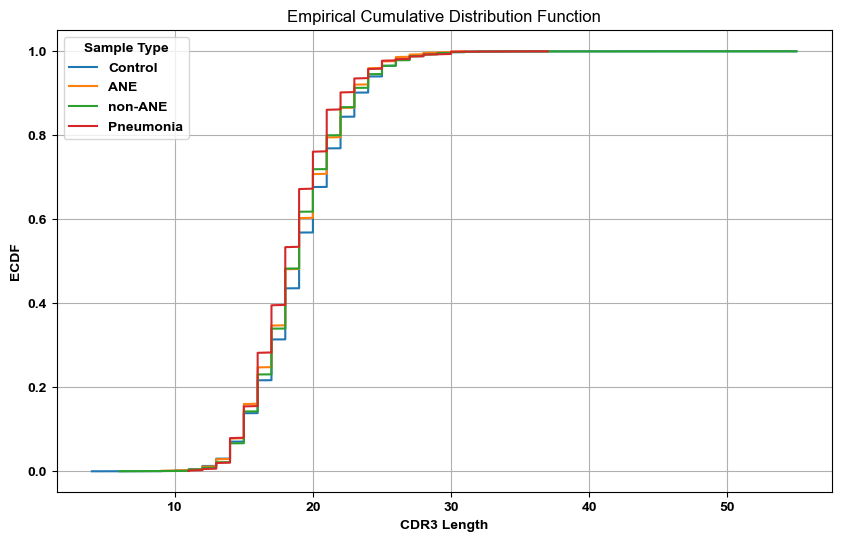

<Figure size 1000x600 with 0 Axes>

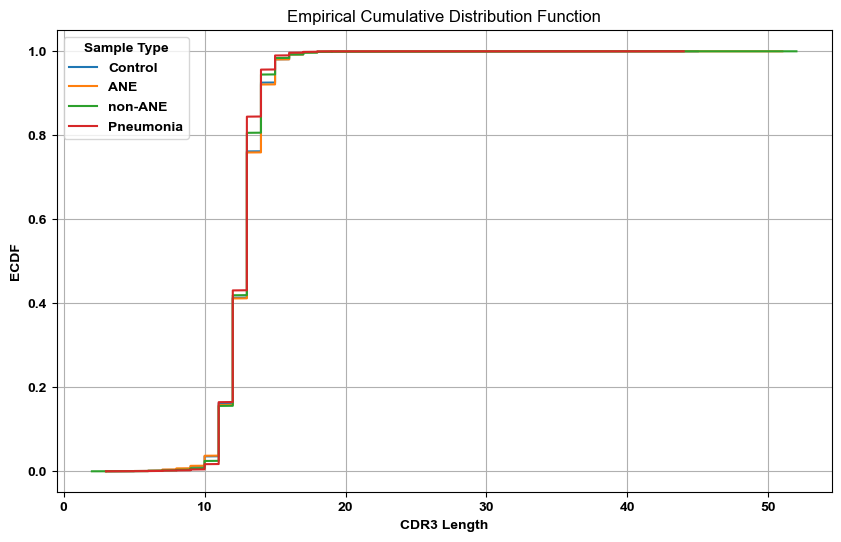

<Figure size 1000x600 with 0 Axes>

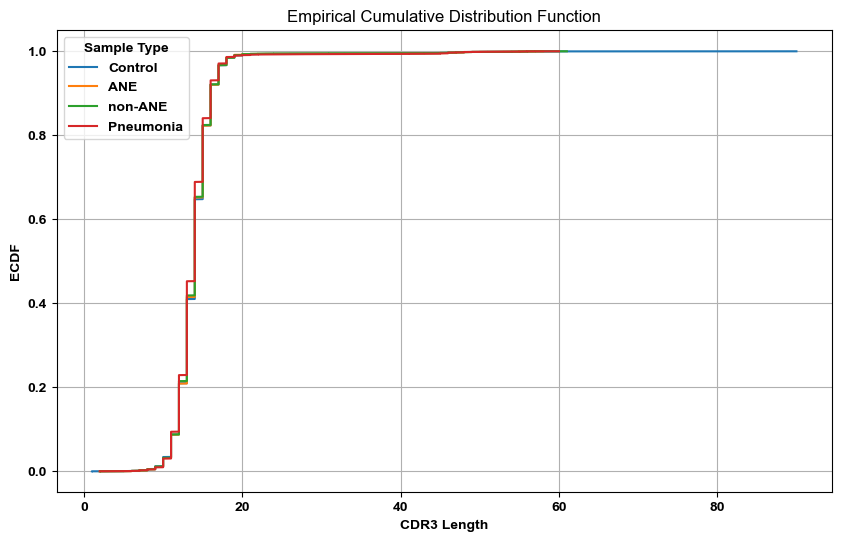

<Figure size 1000x600 with 0 Axes>

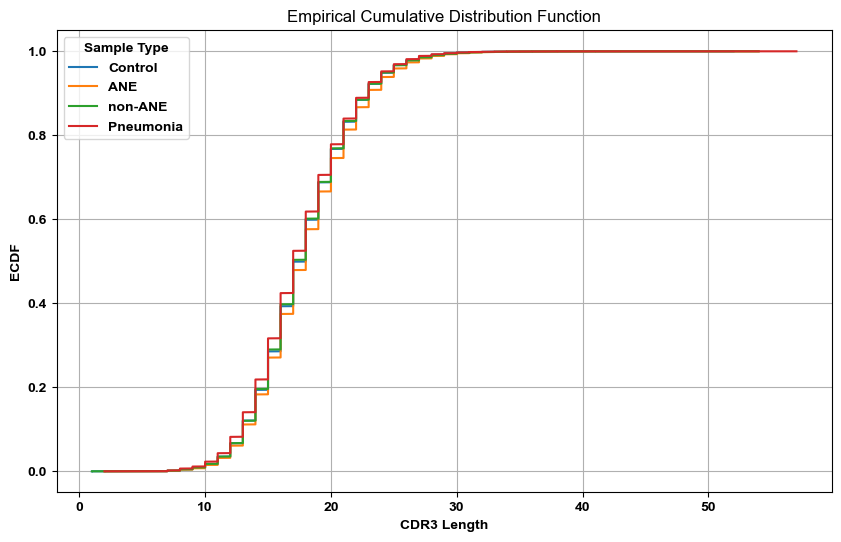

<Figure size 1000x600 with 0 Axes>

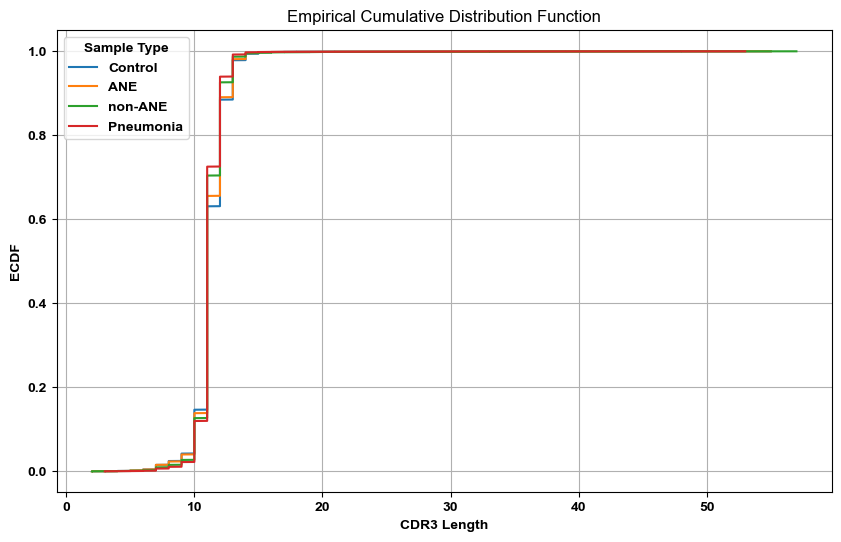

<Figure size 1000x600 with 0 Axes>

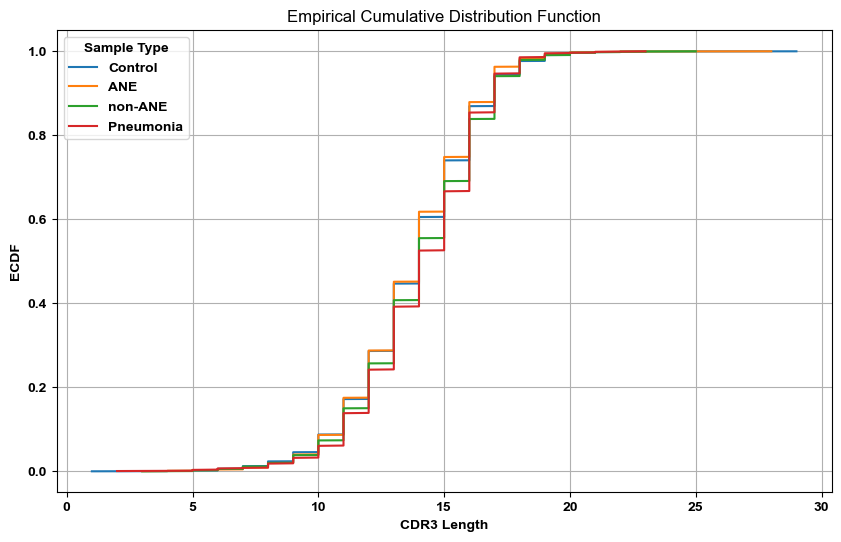

<Figure size 1000x600 with 0 Axes>

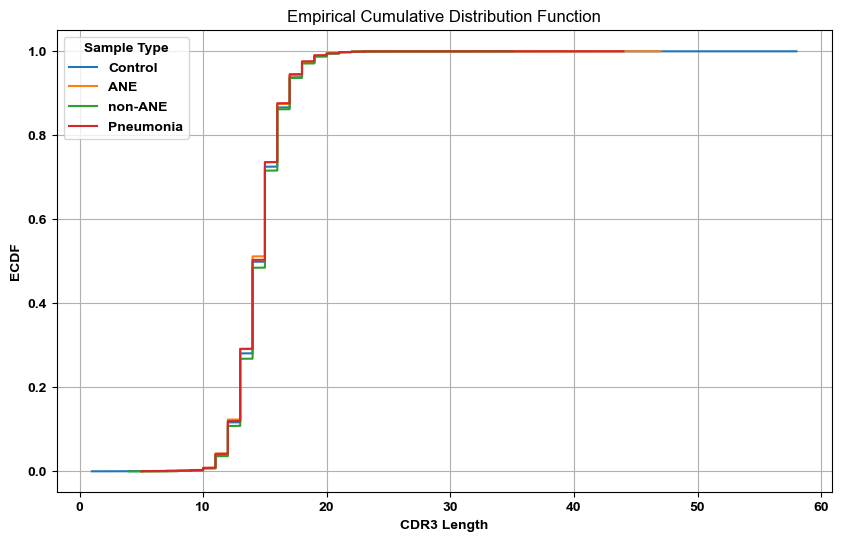

In [5]:

for csv_file in csv_files:
    data = pd.read_csv(csv_file)
    # Remove the first row and set the first column as the index
    data_cleaned = data.drop(0).set_index('CDR3(pep)').dropna(how='all', axis=1)

    # Remove rows where the CDR3 sequence is NaN
    data_cleaned = data_cleaned.dropna(how='all')

    # Calculate the length of each CDR3 sequence and add as a new column
    data_cleaned['CDR3 Length'] = data_cleaned.index.str.len()

    # Extract the sample types from the first row (which were originally in row 0) and apply to the columns
    sample_types = data.iloc[0, 1:]

    # Stack the data and add sample types as a column
    stacked_data = data_cleaned.drop(columns='CDR3 Length').stack().reset_index()
    stacked_data.columns = ['CDR3 Sequence', 'Sample', 'Copy Number']
    stacked_data['Sample Type'] = stacked_data['Sample'].map(sample_types)
    stacked_data['CDR3 Length'] = stacked_data['CDR3 Sequence'].str.len()

    # Drop any rows with missing values for copy number and sample type
    stacked_data = stacked_data.dropna(subset=['Copy Number', 'Sample Type'])

    # Convert copy number to numeric (if not already)
    stacked_data['Copy Number'] = pd.to_numeric(stacked_data['Copy Number'], errors='coerce')
    stacked_data = stacked_data.dropna(subset=['Copy Number'])

    # Now, I will calculate the ECDF for CDR3 length by sample type
    def ecdf(data):
        """Return the x and y values for an ECDF."""
        x = np.sort(data)
        y = np.arange(1, len(x) + 1) / len(x)
        return x, y

    # Generate ECDF plots for each sample type
    plt.figure(figsize=(10, 6))
    sample_types_unique = stacked_data['Sample Type'].unique()
    sample_types_unique = ['Control', 'ANE','non-ANE' , 'Pneumonia']

    # Let's create smooth curves instead of using markers, connecting the ECDF points with lines.

    plt.figure(figsize=(10, 6))
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.weight'] = 'bold'
    # Plot ECDF curves for each sample type with a line connecting the points
    for sample_type in sample_types_unique:
        lengths = stacked_data[stacked_data['Sample Type'] == sample_type]['CDR3 Length']
        x, y = ecdf(lengths)
        plt.plot(x, y, label=sample_type)

    plt.xlabel('CDR3 Length')
    plt.ylabel('ECDF')
    plt.title('Empirical Cumulative Distribution Function')
    plt.legend(title='Sample Type')
    plt.grid(True)
    if not os.path.exists("Results"):
        os.makedirs("Results")
    plt.savefig("./Results/"+csv_file.split('/')[-1].split('.')[0] + '_ECDF.png',dpi=300,bbox_inches='tight')


In [4]:
sample_types_unique

array(['Control', 'ANE', 'Pneumonia', 'non-ANE'], dtype=object)